Processing the LFW Dataset with a CNN - 5/4/2026 - derave1577

### Step 1: Load the Dataset

Date: 2026-05-04

Student ID: derave1577

Data shape: (1288, 1850)
Number of classes: 7
Classes: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


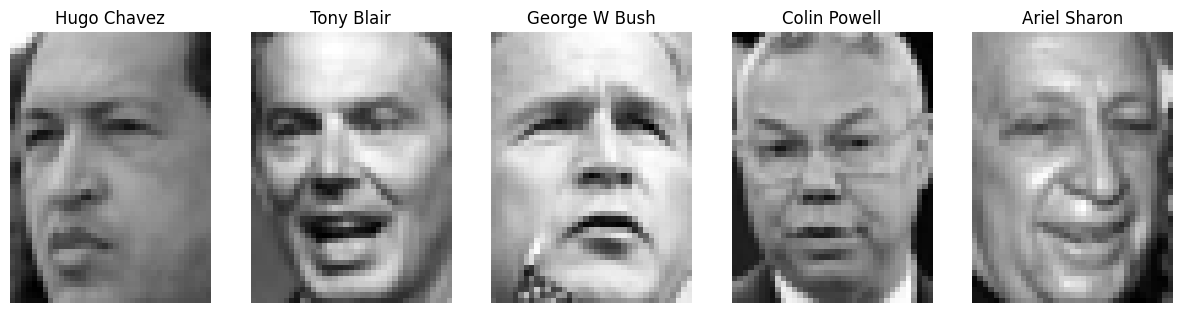

In [1]:
# Import necessary libraries
import os
os.environ["KERAS_BACKEND"] = "torch"
import torch
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.metrics import confusion_matrix
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "derave1577"
# Load the LFW dataset
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
data = lfw_people.data
target = lfw_people.target
target_names = lfw_people.target_names
# Display dataset information
display(Markdown("### Step 1: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
print(f"Data shape: {data.shape}")
print(f"Number of classes: {len(target_names)}")
print(f"Classes: {target_names}")
# Display the first few sample images with their target values
fig, axes = plt.subplots(1, 5, figsize=(15, 6))
for i in range(5):
    axes[i].imshow(data[i].reshape(50, 37), cmap='gray')
    axes[i].set_title(target_names[target[i]])
    axes[i].axis('off')
plt.show()

In [2]:
display(Markdown("### Step 2: Preprocess the data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Normalize the pixel values
data = data / 255.0
# Add additional features if needed (e.g., pixel intensity statistics)
mean_pixel_values = np.mean(data, axis=1).reshape(-1, 1)
std_pixel_values = np.std(data, axis=1).reshape(-1, 1)
# Concatenate the new features with the original data
data_with_features = np.hstack((data, mean_pixel_values, std_pixel_values))
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data_with_features, target, test_size=0.3, random_state=42)
# Convert the target to categorical
y_train_cat = keras.utils.to_categorical(y_train, len(target_names))
y_test_cat = keras.utils.to_categorical(y_test, len(target_names))
print(f"New data shape with engineered features: {data_with_features.shape}")

### Step 2: Preprocess the data

Date: 2026-05-04

Student ID: derave1577

New data shape with engineered features: (1288, 1852)


In [3]:
display(Markdown("### Step 3: Construct and Train the CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Build the neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(data_with_features.shape[1],)), 
    Dropout(0.5),
    Dense(64, activation='relu'), 
    Dropout(0.5),
    Dense(7, activation='softmax')
])
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
# Display the model summary
model.summary()
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)
# Save the model
model.save('face_recognition_model.keras')

### Step 3: Construct and Train the CNN Model

Date: 2026-05-04

Student ID: derave1577

C:\Users\Derek A\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         237,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 245,895 (960.53 KB)

 Trainable params: 245,895 (960.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8892 - sparse_categorical_accuracy: 0.3819 - val_loss: 1.7885 - val_sparse_categorical_accuracy: 0.4088
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7681 - sparse_categorical_accuracy: 0.4028 - val_loss: 1.6676 - val_sparse_categorical_accuracy: 0.4088
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7391 - sparse_categorical_accuracy: 0.4028 - val_loss: 1.6565 - val_sparse_categorical_accuracy: 0.4088
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7453 - sparse_categorical_accuracy: 0.4028 - val_loss: 1.6585 - val_sparse_categorical_accuracy: 0.4088
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7228 - sparse_categorical_accuracy: 0.4042 - val_loss: 1.6621 - val_sparse_categorical_accuracy: 0.4088
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7212 - sparse_categorical_accuracy: 0.4028 - val_loss: 1.6571 - val_sparse_categorical_accuracy: 0.4088
Epoch 7/20
23/23

### Step 4: Evaluating the Model

Date: 2026-05-04

Student ID: derave1577

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6385 - sparse_categorical_accuracy: 0.4289
Test accuracy: 0.4289405643939972
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


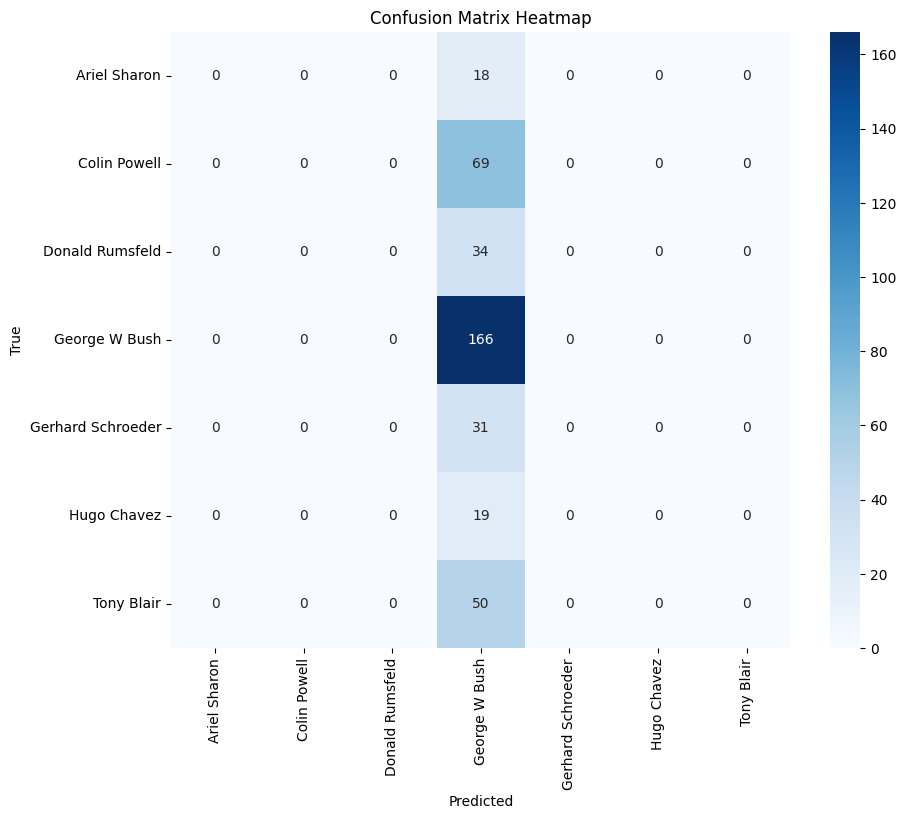

In [5]:
display(Markdown("### Step 4: Evaluating the Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")
# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test
# Display the confusion matrix
confusion_mtx = confusion_matrix(y_true, y_pred_classes)
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=lfw_people.target_names, yticklabels=lfw_people.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [6]:
display(Markdown("### Step 5: Apply PCA for CNN Model Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Perform PCA for dimensionality reduction
pca = PCA(n_components=150, whiten=True, random_state=42)
data_pca = pca.fit_transform(data)
# Add additional features if needed (e.g., pixel intensity statistics)
min_pixel_values = np.min(data_pca, axis=1).reshape(-1, 1)
max_pixel_values = np.max(data_pca, axis=1).reshape(-1, 1)
# Concatenate the new features with the PCA data
data_with_features = np.hstack((data_pca, min_pixel_values, max_pixel_values))
print(f"New data shape with engineered features: {data_with_features.shape}")
# Split the new data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data_with_features, target, test_size=0.3, random_state=42)
# Build the new neural network model
model = Sequential([
    Dense(256, activation='relu', input_shape=(data_with_features.shape[1],)), 
    Dropout(0.5),
    Dense(128, activation='relu'), 
    Dropout(0.5),
    Dense(7, activation='softmax')
])
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
# Display the model summary
model.summary()

### Step 5: Apply PCA for CNN Model Tuning

Date: 2026-05-04

Student ID: derave1577

New data shape with engineered features: (1288, 152)


C:\Users\Derek A\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 256)                 │          39,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 72,967 (285.03 KB)

 Trainable params: 72,967 (285.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1597 - sparse_categorical_accuracy: 0.9500 - val_loss: 0.7900 - val_sparse_categorical_accuracy: 0.8177
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1474 - sparse_categorical_accuracy: 0.9583 - val_loss: 0.7787 - val_sparse_categorical_accuracy: 0.8122
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1193 - sparse_categorical_accuracy: 0.9583 - val_loss: 0.7786 - val_sparse_categorical_accuracy: 0.8066
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1206 - sparse_categorical_accuracy: 0.9681 - val_loss: 0.8078 - val_sparse_categorical_accuracy: 0.8066
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1221 - sparse_categorical_accuracy: 0.9556 - val_loss: 0.8223 - val_sparse_categorical_accuracy: 0.8066
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1036 - sparse_categorical_accuracy: 0.9708 - val_loss: 0.8343 - val_sparse_categorical_accuracy: 0.8177
Epoch 7/20
23/23

### Step 6: Evaluate the Adjusted CNN Models

Date: 2026-05-04

Student ID: derave1577

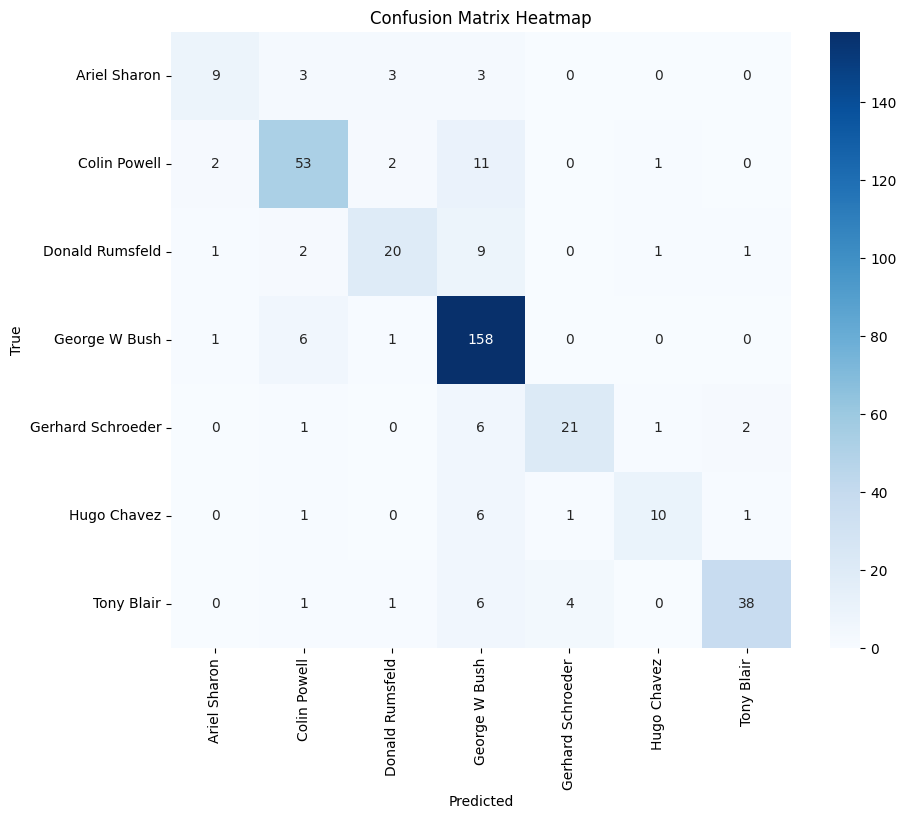

In [8]:
# Train the model
PCA_history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)
# Save the model
model.save('face_recognition_model_with_features.keras')
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")
# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test
display(Markdown("### Step 6: Evaluate the Adjusted CNN Models"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Display the confusion matrix
confusion_mtx = confusion_matrix(y_true, y_pred_classes)
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=lfw_people.target_names, yticklabels=lfw_people.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Step 7: Visualizing Model Performance

Date: 2026-05-04

Student ID: derave1577

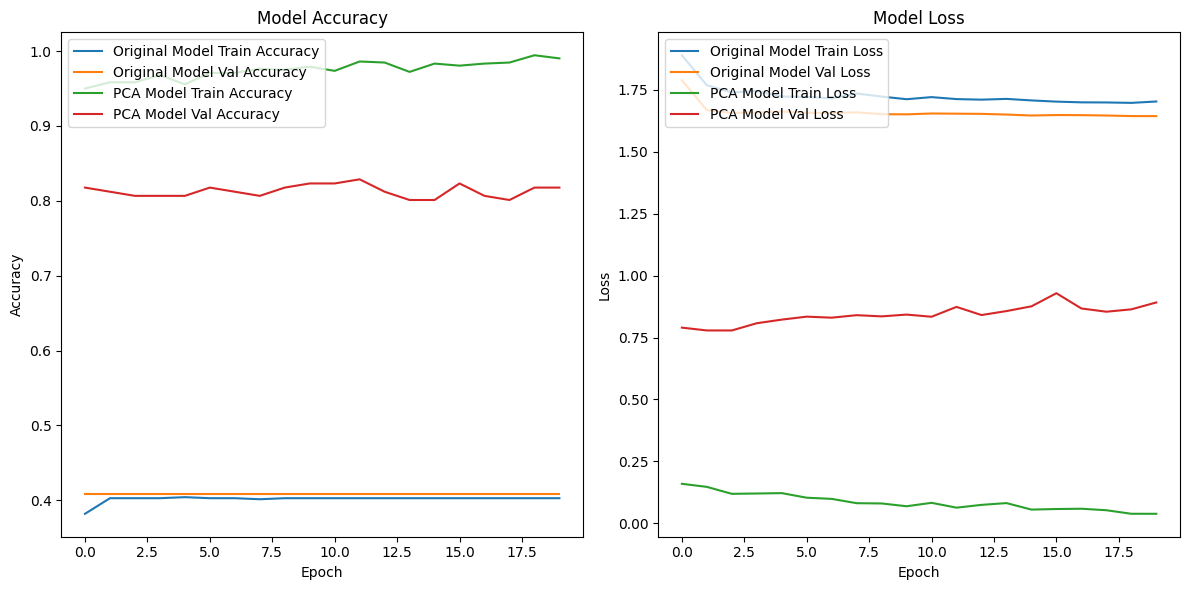

In [9]:
display(Markdown("### Step 7: Visualizing Model Performance"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Plot training & validation accuracy values for both old and new models
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['sparse_categorical_accuracy'], label='Original Model Train Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Original Model Val Accuracy')
plt.plot(PCA_history.history['sparse_categorical_accuracy'], label='PCA Model Train Accuracy')
plt.plot(PCA_history.history['val_sparse_categorical_accuracy'], label='PCA Model Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
# Plot training & validation loss values for both old and new models
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Original Model Train Loss')
plt.plot(history.history['val_loss'], label='Original Model Val Loss')
plt.plot(PCA_history.history['loss'], label='PCA Model Train Loss')
plt.plot(PCA_history.history['val_loss'], label='PCA Model Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()